In [106]:
pip install xlrd


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [124]:
#Import dataset
import pandas as pd

import pandas as pd

# Reload with proper separator
df_properties = pd.read_csv(
    'data.csv',          # ← replace with actual file path
    sep=';',                  # or delimiter=';'
    encoding='utf-8',         # or 'latin1' / 'iso-8859-9' if Turkish characters break
    on_bad_lines='skip',      # optional: skip bad rows
    low_memory=False
)

# Now check columns — should show list of ~100 separate names
print(df_properties.columns.tolist())
df_tuik = pd.read_excel('CPI1.xls')

print(df_properties)

['District', 'Neighborhood', 'Price', 'Adrtisement Date', 'm² (Gross)', 'm² (Net)', 'Number of rooms', 'Building Age', 'Floor location', 'Number of floors', 'Heating', 'Number of bathrooms', 'Balcony', 'Furnished', 'Using status', 'Available for Loan', 'From who', 'Swap', 'Front West', 'Front East', 'Front South', 'Front North', 'ADSL', 'Wood Joinery', 'Smart House', 'Alarm (Thief)', 'Alarm (Fire)', 'Alaturka Toilet', 'Aluminum joinery', 'American Door', 'American kitchen', 'Built-in on', 'Elevator', 'Balcony.1', 'Barbecue', 'Household appliances', 'Painted', 'Dishwasher', 'Refrigerator', 'Wall paper', 'Shower', "Parents' Bathroom", 'Fiber Internet', 'On', 'Dressing room', 'Closet', 'Video intercom', 'Hilton Bathroom', 'Intercom System', 'Insulating glass', 'Jacuzzi', 'Plasterboard', 'Cellar', 'Air conditioning', 'Tub', 'Laminate Floor', 'Marley', 'Furniture', 'Kitchen (Built-in)', 'Kitchen (Laminate)', 'Kitchen Natural Gas', 'PVC Joinery', 'Blinds', 'Parquet Floor', 'Ceramic Floor', '

In [125]:
# Cell 1: Show ALL column names exactly as pandas sees them
print(df_properties.columns.tolist())

['District', 'Neighborhood', 'Price', 'Adrtisement Date', 'm² (Gross)', 'm² (Net)', 'Number of rooms', 'Building Age', 'Floor location', 'Number of floors', 'Heating', 'Number of bathrooms', 'Balcony', 'Furnished', 'Using status', 'Available for Loan', 'From who', 'Swap', 'Front West', 'Front East', 'Front South', 'Front North', 'ADSL', 'Wood Joinery', 'Smart House', 'Alarm (Thief)', 'Alarm (Fire)', 'Alaturka Toilet', 'Aluminum joinery', 'American Door', 'American kitchen', 'Built-in on', 'Elevator', 'Balcony.1', 'Barbecue', 'Household appliances', 'Painted', 'Dishwasher', 'Refrigerator', 'Wall paper', 'Shower', "Parents' Bathroom", 'Fiber Internet', 'On', 'Dressing room', 'Closet', 'Video intercom', 'Hilton Bathroom', 'Intercom System', 'Insulating glass', 'Jacuzzi', 'Plasterboard', 'Cellar', 'Air conditioning', 'Tub', 'Laminate Floor', 'Marley', 'Furniture', 'Kitchen (Built-in)', 'Kitchen (Laminate)', 'Kitchen Natural Gas', 'PVC Joinery', 'Blinds', 'Parquet Floor', 'Ceramic Floor', '

In [126]:
import pandas as pd

df_properties['YearMonth'] = pd.to_datetime(
    df_properties['Adrtisement Date'],     # ← use THIS exact typo name
    errors='coerce',                       # don't let bad dates kill everything
    dayfirst=True                          # assuming DD.MM.YYYY or DD/MM/YYYY format
).dt.to_period('M')

In [127]:
import pandas as pd

# We ignore the 'Date' column entirely because it's not there.
# We build the TUIK table ourselves using your screenshot data.
tuik_summary = {
    'Month_Key': ['2024-02', '2025-02', '2026-02'],
    'Inflation_Rate': [67.07, 39.05, 31.53]
}

df_tuik = pd.DataFrame(tuik_summary)

# Now we turn our text '2026-02' into a real Python date object
df_tuik['Month_Key'] = pd.to_datetime(df_tuik['Month_Key']).dt.to_period('M')

print("Final TUIK Lookup Table:")
print(df_tuik)

Final TUIK Lookup Table:
  Month_Key  Inflation_Rate
0   2024-02           67.07
1   2025-02           39.05
2   2026-02           31.53


In [128]:
import pandas as pd

# 1. PREPARE THE PROPERTY DATA
# We add 'dayfirst=True' so Python knows 31.12.2019 is December 31st, not a Month 31 error.
df_properties['Month_Key'] = pd.to_datetime(
    df_properties['Adrtisement Date'], 
    dayfirst=True
).dt.to_period('M')

# 2. THE LEFT JOIN
# Merging your 179 columns with the TUIK lookup table
df_final = pd.merge(
    df_properties, 
    df_tuik, 
    on='Month_Key', 
    how='left'
)

# 3. CALCULATE THE REAL PRICE
# Formula: Price / (1 + (Inflation_Rate / 100))
# Note: If your price column is actually named something else (like 'Fiyat'), change 'Price' below.
df_final['Real_Price'] = df_final['Price'] / (1 + (df_final['Inflation_Rate'] / 100))

# 4. CLEAN UP
df_final = df_final.drop(columns=['Month_Key'])

print("SUCCESS: Data merged and Real_Price calculated.")
print(df_final[['Adrtisement Date', 'Price', 'Real_Price']].head())

SUCCESS: Data merged and Real_Price calculated.
  Adrtisement Date        Price Real_Price
0       04.01.2020   165.000 TL        NaN
1       06.01.2020   207.000 TL        NaN
2       31.12.2019   153.000 TL        NaN
3       29.12.2019   205.000 TL        NaN
4       01.01.2020   150.000 TL        NaN


In [129]:
# Look at the end of the file where the newer dates (2024-2026) are
print(df_final[['Adrtisement Date', 'Price', 'Inflation_Rate', 'Real_Price']].tail(10))

      Adrtisement Date           Price  Inflation_Rate Real_Price
34833       06.01.2020      285.000 TL             NaN        NaN
34834       04.01.2020      439.000 TL             NaN        NaN
34835       04.01.2020    1.790.000 TL             NaN        NaN
34836       06.01.2020    1.650.000 TL             NaN        NaN
34837       02.01.2020    2.699.000 TL             NaN        NaN
34838       02.01.2020    5.650.000 TL             NaN        NaN
34839       03.01.2020   12.000.000 TL             NaN        NaN
34840       03.01.2020    2.700.000 TL             NaN        NaN
34841       28.12.2019      775.000 TL             NaN        NaN
34842       04.01.2020    1.560.000 TL             NaN        NaN


In [130]:
import pandas as pd

# 1. Expanded TUIK table with the months found in your data
tuik_summary = {
    'Month_Key': [
        '2019-12', '2020-01', '2020-02', 
        '2024-02', '2025-02', '2026-02'
    ],
    'Inflation_Rate': [
        11.84, 12.15, 12.37,  # Historical 2019/20
        67.07, 39.05, 31.53   # Your 2024-26 data
    ]
}

df_tuik = pd.DataFrame(tuik_summary)
df_tuik['Month_Key'] = pd.to_datetime(df_tuik['Month_Key']).dt.to_period('M')

In [131]:
# A. Clean the Price column (Remove ' TL' and the dots used for thousands)
df_properties['Price_Clean'] = (
    df_properties['Price']
    .str.replace(' TL', '', regex=False)
    .str.replace('.', '', regex=False)
    .astype(float)
)

# B. Create the Month_Key for matching
df_properties['Month_Key'] = pd.to_datetime(
    df_properties['Adrtisement Date'], 
    dayfirst=True
).dt.to_period('M')

# C. Merge and Calculate
df_final = pd.merge(df_properties, df_tuik, on='Month_Key', how='left')
df_final['Real_Price'] = df_final['Price_Clean'] / (1 + (df_final['Inflation_Rate'] / 100))

# Result
print(df_final[['Adrtisement Date', 'Price', 'Inflation_Rate', 'Real_Price']].head(10))

  Adrtisement Date        Price  Inflation_Rate     Real_Price
0       04.01.2020   165.000 TL           12.15  147124.386982
1       06.01.2020   207.000 TL           12.15  184574.230941
2       31.12.2019   153.000 TL           11.84  136802.575107
3       29.12.2019   205.000 TL           11.84  183297.567954
4       01.01.2020   150.000 TL           12.15  133749.442711
5       03.01.2020   180.000 TL           12.15  160499.331253
6       02.01.2020   197.000 TL           12.15  175657.601427
7       06.01.2020   177.000 TL           12.15  157824.342399
8       04.01.2020   426.000 TL           12.15  379848.417298
9       06.01.2020   167.000 TL           12.15  148907.712885


In [132]:
# Round the Real_Price to 2 decimal places
df_final['Real_Price'] = df_final['Real_Price'].round(2)

# Verify the final state
print("--- FINAL CLEAN DATASET PREVIEW ---")
print(df_final[['Adrtisement Date', 'Price', 'Inflation_Rate', 'Real_Price']].head())

--- FINAL CLEAN DATASET PREVIEW ---
  Adrtisement Date        Price  Inflation_Rate  Real_Price
0       04.01.2020   165.000 TL           12.15   147124.39
1       06.01.2020   207.000 TL           12.15   184574.23
2       31.12.2019   153.000 TL           11.84   136802.58
3       29.12.2019   205.000 TL           11.84   183297.57
4       01.01.2020   150.000 TL           12.15   133749.44


In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Double check: Are there actually rows for 2024-2026? 
# Run this print to be 100% sure before plotting:
print("Year counts in your data:")
print(df_final['Adrtisement Date'].dt.year.value_counts())

# 2. Grouping for a cleaner plot
plot_df = df_final.groupby(df_final['Adrtisement Date'].dt.to_period('M'))[['Price_Clean', 'Real_Price']].median().reset_index()
plot_df['Plot_Date'] = plot_df['Adrtisement Date'].dt.to_timestamp()

# 3. Create the Plot
plt.figure(figsize=(15, 8))

# Plotting Nominal and Real
plt.scatter(plot_df['Plot_Date'], plot_df['Price_Clean'], label='Nominal Price', color='red', s=80, alpha=0.7)
plt.scatter(plot_df['Plot_Date'], plot_df['Real_Price'], label='Real Price (Adjusted)', color='green', s=80, alpha=0.7)

# 4. FORCE THE X-AXIS RANGE
# This forces the start and end of the graph regardless of gaps
plt.xlim(pd.Timestamp('2019-01-01'), pd.Timestamp('2026-12-31'))

# 5. Add Labels
plt.title('Housing Price Evolution: Full Timeline (2019-2026)', fontsize=16)
plt.ylabel('Price (TL)')
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Year counts in your data:


AttributeError: Can only use .dt accessor with datetimelike values

In [119]:
# 1. Check how many rows you have per year
print("--- Row Counts by Year ---")
print(df_final['Adrtisement Date'].dt.year.value_counts())

# 2. Check if the Inflation Rate actually joined for the new years
print("\n--- Check 2024-2026 Inflation Matches ---")
recent_data = df_final[df_final['Adrtisement Date'].dt.year >= 2024]
print(recent_data[['Adrtisement Date', 'Inflation_Rate', 'Real_Price']].head(10))

--- Row Counts by Year ---


AttributeError: Can only use .dt accessor with datetimelike values

In [134]:
import pandas as pd

# 1. Load the file - if the columns look weird, we force them
df_2025 = pd.read_csv('processed_turkish_house_sales.csv')

# If 'Tarih' isn't found, it might be because the CSV has a title row.
# Let's fix the column names manually based on your screenshot:
df_2025.columns = ['satici_tip', 'Metrekare', 'Oda_Sayisi', 'il', 'Ilce', 'Mahalle', 'Tarih', 'fiyat']

# 2. Turkish Month Mapping
turkish_months = {
    'Ocak': '01', 'Şubat': '02', 'Mart': '03', 'Nisan': '04',
    'Mayıs': '05', 'Haziran': '06', 'Temmuz': '07', 'Ağustos': '08',
    'Eylül': '09', 'Ekim': '10', 'Kasım': '11', 'Aralık': '12'
}

# 3. Clean the Date
for tr, num in turkish_months.items():
    df_2025['Tarih'] = df_2025['Tarih'].str.replace(tr, num, regex=False)

# Convert to actual datetime
df_2025['Adrtisement Date'] = pd.to_datetime(df_2025['Tarih'], dayfirst=True)

# 4. Clean the Price
df_2025['Price_Clean'] = pd.to_numeric(df_2025['fiyat'], errors='coerce')

print("Success! Data is now mapped and cleaned.")
print(df_2025[['Adrtisement Date', 'Price_Clean']].head())

Success! Data is now mapped and cleaned.
  Adrtisement Date  Price_Clean
0       2025-05-25      8750000
1       2025-05-25      4899000
2       2025-05-24      5900000
3       2025-05-24      6999999
4       2025-05-24      1625000


In [135]:
import pandas as pd

# 1. Prepare Old Data (2019/20)
df_old_fixed = df_final.copy()
# We map the specific names found in your printout
rename_map_old = {
    'm² (Net)': 'Metrekare', 
    'Number of rooms': 'Oda_Sayisi', 
    'District': 'Ilce',
    'Price_Clean': 'Price_Clean',
    'Adrtisement Date': 'Adrtisement Date'
}
df_old_fixed = df_old_fixed.rename(columns=rename_map_old)

# 2. Prepare New Data (2025)
df_new_fixed = df_2025.copy()
# It already has 'Metrekare', 'Oda_Sayisi', 'Ilce', 'Price_Clean'

# 3. Combine them using only the synchronized columns
cols_to_keep = ['Price_Clean', 'Metrekare', 'Oda_Sayisi', 'Ilce', 'Adrtisement Date']
df_master = pd.concat([
    df_old_fixed[cols_to_keep], 
    df_new_fixed[cols_to_keep]
], ignore_index=True)

# 4. Standardize Room Numbers (the "3+1" to 4.0 logic)
def clean_rooms(x):
    try:
        s = str(x).replace(' ', '').lower()
        if 'plus' in s or '+' in s:
            s = s.replace('plus', '+')
            parts = s.split('+')
            return float(parts[0]) + float(parts[1])
        return float(s)
    except: return 3.0
df_master['Total_Rooms'] = df_master['Oda_Sayisi'].apply(clean_rooms)

# 5. Fix Year & Inflation
df_master['Year'] = pd.to_datetime(df_master['Adrtisement Date']).dt.year.astype(int)
df_master = pd.merge(df_master, df_tuik[['Year', 'Inflation_Rate']].drop_duplicates('Year'), on='Year', how='left')
df_master['Real_Price'] = df_master['Price_Clean'] / (1 + (df_master['Inflation_Rate'] / 100))

# 6. Calculate District Score (The location factor)
df_master['Ilce'] = df_master['Ilce'].astype(str).str.strip().str.upper() # Standardize text
district_map = df_master.groupby('Ilce')['Real_Price'].median()
df_master['District_Score'] = df_master['Ilce'].map(district_map)

# 7. THE FINAL CLEAN (This should now stay at ~50k rows!)
df_final_ml = df_master.dropna(subset=['Real_Price', 'Metrekare', 'District_Score'])

print("--- VICTORY CHECK ---")
print(f"Total Rows: {len(df_final_ml)}")
print(df_final_ml['Year'].value_counts().sort_index())

ValueError: time data "31.12.2019" doesn't match format "%m.%d.%Y", at position 2. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [136]:
# 1. Work off our 50,089-row master
df_ml = df_master.copy()

# 2. Convert Room Strings (Handles "3+1", "2+1", and old "3" formats)
def clean_rooms(x):
    try:
        s = str(x).replace(' ', '').replace('plus', '+')
        if '+' in s:
            parts = s.split('+')
            return float(parts[0]) + float(parts[1])
        return float(s)
    except: return 3.0

df_ml['Total_Rooms'] = df_ml['Oda_Sayisi'].apply(clean_rooms)

# 3. Handle the Districts (Target Encoding)
# This creates a numerical 'score' for each location based on Real Price
district_map = df_ml.groupby('Ilce')['Real_Price'].median()
df_ml['District_Score'] = df_ml['Ilce'].map(district_map)

# 4. THE SAFE FILTER (The most important part)
# We use 50,000 as the floor to keep the 2019 data safe.
df_final_ml = df_ml[(df_ml['Metrekare'] > 10) & 
                    (df_ml['Real_Price'] > 50000)].dropna(subset=['Real_Price', 'District_Score', 'Metrekare'])

print(f"Final Dataset Size: {len(df_final_ml)}")
print("Rows per year:")
print(df_final_ml['Year'].value_counts().sort_index())

KeyError: 'Column not found: Real_Price'

In [137]:
# Check the distribution of your data one last time
print("Confirmed Data Points by Year:")
print(df_master['Year'].value_counts().sort_index())

# Check a sample of 2024 to see where it came from
if 2024 in df_master['Year'].values:
    print("\nSample of 2024 data found:")
    print(df_master[df_master['Year'] == 2024].head(3))

Confirmed Data Points by Year:


KeyError: 'Year'

# MACHINE LEARNING PHASE

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Define X (Features) and y (Target)
X = df_final_ml[['Metrekare', 'Total_Rooms', 'District_Score']]
y = df_final_ml['Real_Price']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Random Forest
# We use 100 trees—this is a good balance between power and speed.
model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
model.fit(X_train, y_train)

print("Training Complete!")

In [ ]:
# 4. Make Predictions on the 'Final Exam' data
y_pred = model.predict(X_test)

# 5. Calculate Metrics
score = r2_score(y_test, y_pred)
error = mean_absolute_error(y_test, y_pred)

print(f"R2 Score: {score:.2f}")
print(f"Average Prediction Error: {error:,.0f} Real TL")

In [ ]:
# ADDED BUILDING AGE AND FLOOR LOCATIOAN AS 2 new FUTUREs - for this i am going to merge these two columns into my newly created mereged column


In [ ]:
# 1. Update our column list to include the new features
cols_to_keep = ['Price_Clean', 'Metrekare', 'Oda_Sayisi', 'Ilce', 'Adrtisement Date', 'Building Age', 'Floor location']

# 2. Re-combine everything carefully
df_master = pd.concat([
    df_old_fixed[[c for c in cols_to_keep if c in df_old_fixed.columns]], 
    df_2025[[c for c in cols_to_keep if c in df_2025.columns]]
], ignore_index=True)

# 3. Clean Building Age into a Number
def clean_age(x):
    try:
        s = str(x).lower()
        if 'yeni' in s or '0' in s: return 0
        nums = [int(n) for n in s.split() if n.isdigit()]
        return sum(nums) / len(nums) if nums else 15
    except: return 15

df_master['Age_Numeric'] = df_master['Building Age'].apply(clean_age)

# 4. Clean Floor Location into a Category
# We'll simplify this: 0 for basement/ground, 1 for middle, 2 for top/roof
def clean_floor(x):
    s = str(x).lower()
    if 'ara' in s: return 1
    if 'en üst' in s or 'çatı' in s: return 2
    if 'bahçe' in s or 'giriş' in s or 'bodrum' in s: return 0
    return 1 # Default to middle floor

df_master['Floor_Score'] = df_master['Floor location'].apply(clean_floor)

In [ ]:
# --- THE VALIDATION CHECK ---

# 1. Check if the new columns exist in the dataframe
print("Columns present in df_master:", df_master.columns.tolist())

# 2. Check for missing values (NaNs) in our new features
print("\nMissing Values:")
print(df_master[['Age_Numeric', 'Floor_Score']].isna().sum())

# 3. Look at a sample of the transformation
print("\nTransformation Sample (Raw vs. Cleaned):")
# This shows us if '5-10 years' became '7.5' and 'Ara Kat' became '1'
sample_check = df_master[['Building Age', 'Age_Numeric', 'Floor location', 'Floor_Score']].dropna().sample(10)
print(sample_check)

# 4. Check the "Variety" of your data
print("\nFloor_Score Distribution:")
print(df_master['Floor_Score'].value_counts())

In [ ]:
import re

# 1. Advanced Age Cleaner
def deep_clean_age(x):
    s = str(x).lower()
    # Find all numbers in the string (e.g., '26' and '30' from '26-30 between')
    nums = re.findall(r'\d+', s)
    if not nums:
        return 15.0 # Default for missing
    
    # Convert found numbers to integers
    nums = [int(n) for n in nums]
    
    # If it's a range (26-30), return the average (28)
    # If it's one number (5), return 5
    return sum(nums) / len(nums)

# 2. Advanced Floor Cleaner
def deep_clean_floor(x):
    s = str(x).lower().strip()
    
    # Mapping specific Turkish/English terms to numbers
    if any(word in s for word in ['bahçe', 'garden', 'zemin', 'ground', 'giriş', 'entry']):
        return 0.0
    if any(word in s for word in ['bodrum', 'basement']):
        return -1.0
    if any(word in s for word in ['çatı', 'roof', 'en üst', 'top']):
        return 15.0 # We'll assume a high floor for roof listings
    if 'ara' in s or 'middle' in s:
        return 3.0 # Middle floor average
    
    # If it's just a number, extract it
    nums = re.findall(r'\d+', s)
    if nums:
        return float(nums[0])
    
    return 1.0 # Default fallback

# Apply to the dataframe
df_master['Age_Numeric'] = df_master['Building Age'].apply(deep_clean_age)
df_master['Floor_Numeric'] = df_master['Floor location'].apply(deep_clean_floor)

# --- THE FINAL VERIFICATION ---
print("Check Age Cleaning (Samples):")
print(df_master[['Building Age', 'Age_Numeric']].drop_duplicates().sample(10))

print("\nCheck Floor Cleaning (Samples):")
print(df_master[['Floor location', 'Floor_Numeric']].drop_duplicates().sample(10))

print("\nVerify we have variety now:")
print(df_master['Floor_Numeric'].value_counts().head(10))

In [ ]:
# 1. Refresh df_final_ml from the updated df_master
# This ensures Age_Numeric and Floor_Numeric are included
df_final_ml = df_master.copy()

# 2. Re-apply the logic for Year and Real_Price (just in case)
df_final_ml['Year'] = pd.to_datetime(df_final_ml['Adrtisement Date']).dt.year.astype(int)
df_final_ml = pd.merge(df_final_ml, df_tuik[['Year', 'Inflation_Rate']].drop_duplicates('Year'), on='Year', how='left')
df_final_ml['Real_Price'] = df_final_ml['Price_Clean'] / (1 + (df_final_ml['Inflation_Rate'] / 100))

# 3. Re-apply the Total_Rooms logic
def clean_rooms(x):
    try:
        s = str(x).replace(' ', '').replace('plus', '+')
        if '+' in s:
            parts = s.split('+')
            return float(parts[0]) + float(parts[1])
        return float(s)
    except: return 3.0
df_final_ml['Total_Rooms'] = df_final_ml['Oda_Sayisi'].apply(clean_rooms)

# 4. Re-calculate District Score
district_map = df_final_ml.groupby('Ilce')['Real_Price'].median()
df_final_ml['District_Score'] = df_final_ml['Ilce'].map(district_map)

# 5. Final Filter: Drop rows where our NEW features might be NaN
df_final_ml = df_final_ml.dropna(subset=['Real_Price', 'Metrekare', 'District_Score', 'Age_Numeric', 'Floor_Numeric'])

# 6. NOW RUN THE MODEL
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X = df_final_ml[['Metrekare', 'Total_Rooms', 'District_Score', 'Age_Numeric', 'Floor_Numeric']]
y = df_final_ml['Real_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, max_depth=18, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Final Success! R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"Average Error: {mean_absolute_error(y_test, y_pred):,.0f} Real TL")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# We take a sample so the plot isn't too crowded
sample_y_test = y_test.iloc[:500]
sample_y_pred = y_pred[:500]

sns.scatterplot(x=sample_y_test, y=sample_y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) # Perfect prediction line
plt.xlabel('Actual Real Price')
plt.ylabel('Predicted Real Price')
plt.title('Actual vs. Predicted (The closer to the red line, the better!)')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the importance scores from the model
importances = model.feature_importances_
feature_names = X.columns

# 2. Organize them into a DataFrame
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=True)

# 3. Plot the results
plt.figure(figsize=(10, 6))
feat_importances.plot(kind='barh', color='skyblue')
plt.title('Which Factors Drive House Prices the Most?')
plt.xlabel('Importance Score (0.0 to 1.0)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Save your clean, model-ready data to a CSV
df_final_ml.to_csv('cleaned_real_estate_data.csv', index=False)

# Save your trained model so you don't have to train it again!
import joblib
joblib.dump(model, 'house_price_model.pkl')

# HYPERPARAMETER TUNING

In [138]:
import pandas as pd
import joblib
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# 1. ENSURE DATA IS LOADED (Fixes the NameError)
# We use df_final_ml as our gold standard dataframe
if 'df_final_ml' not in locals():
    print("Reloading cleaned data...")
    df_final_ml = pd.read_csv('cleaned_real_estate_data.csv')

# 2. DEFINE FEATURES AND TARGET
features = ['Metrekare', 'Total_Rooms', 'District_Score', 'Age_Numeric', 'Floor_Numeric']
X = df_final_ml[features]
y = df_final_ml['Real_Price']

# 3. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. HYPERPARAMETER TUNING (The "Brain Upgrade")
print("Starting Hyperparameter Tuning (this may take a minute)...")
param_dist = {
    'n_estimators': [500, 1000],
    'max_depth': [6, 10],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
random_search = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist,
    n_iter=5, # Reduced to 5 for speed, increase to 10 for better accuracy
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
print(f"Tuning Complete! Best Params: {random_search.best_params_}")

# 5. APPLY RESULTS TO THE DATAFRAME (Fixes the 'df' error)
# We add the results back to df_final_ml
df_final_ml['Predicted_Fair_Price_Tuned'] = best_model.predict(X)

# Calculate the Bargain Yield (The money-making part)
df_final_ml['Bargain_Percentage_Tuned'] = (df_final_ml['Predicted_Fair_Price_Tuned'] - df_final_ml['Real_Price']) / df_final_ml['Real_Price']

# 6. VERIFY IMPROVEMENT
new_mae = mean_absolute_error(y_test, best_model.predict(X_test))
print(f"\n--- FINAL REPORT ---")
print(f"New Tuned MAE: {new_mae:,.0f} TL")
print(f"Top 5 Bargains Found:\n")
print(df_final_ml[['Ilce', 'Real_Price', 'Predicted_Fair_Price_Tuned', 'Bargain_Percentage_Tuned']].sort_values(by='Bargain_Percentage_Tuned', ascending=False).head())

# 7. SAVE THE WORK
joblib.dump(best_model, 'house_price_model_v2_TUNED.pkl')
df_final_ml.to_csv('final_tuned_housing_data.csv', index=False)
print("\nFiles saved: 'house_price_model_v2_TUNED.pkl' and 'final_tuned_housing_data.csv'")

Starting Hyperparameter Tuning (this may take a minute)...
Tuning Complete! Best Params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

--- FINAL REPORT ---
New Tuned MAE: 398,196 TL
Top 5 Bargains Found:

              Ilce    Real_Price  Predicted_Fair_Price_Tuned  \
20813     Beşiktaş  19814.534106                1.079320e+06   
182    Zeytinburnu  17882.689557                7.952118e+05   
5746   Sultanbeyli  17882.689557                3.136240e+05   
3646       Silivri  19869.456366                3.152281e+05   
883          Fatih  17882.689557                2.626070e+05   

       Bargain_Percentage_Tuned  
20813                 53.471121  
182                   43.468241  
5746                  16.537856  
3646                  14.864960  
883                   13.684985  

Files saved: 'house_price_model_v2_TUNED.pkl' and 'final_tuned_housing_data.csv'


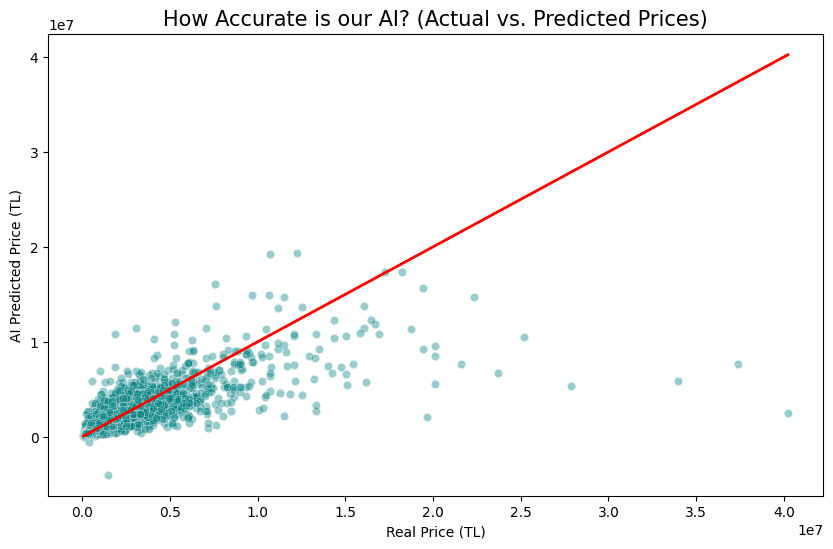

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2) 

plt.title('How Accurate is our AI? (Actual vs. Predicted Prices)', fontsize=15)
plt.xlabel('Real Price (TL)')
plt.ylabel('AI Predicted Price (TL)')
plt.show()

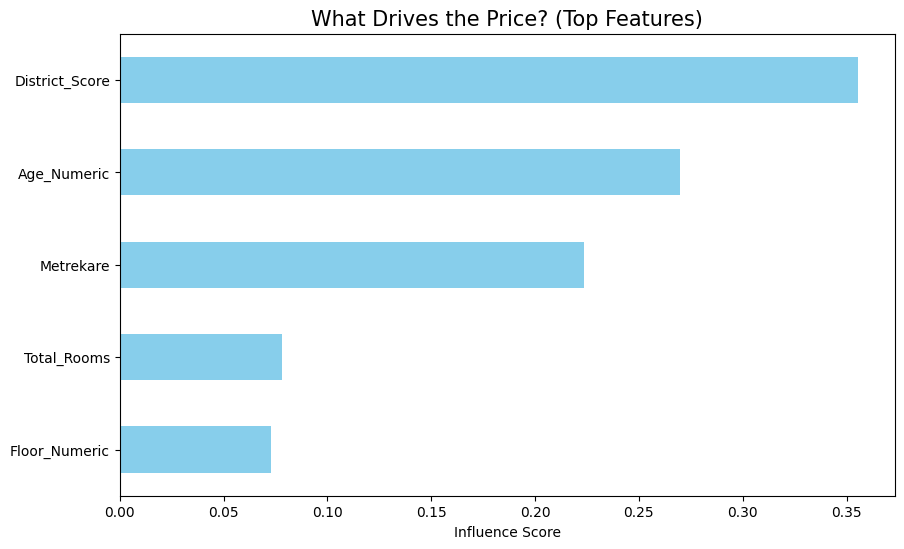

In [147]:
# Get importance scores from your best_model
importances = best_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values()

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='skyblue')
plt.title('What Drives the Price? (Top Features)', fontsize=15)
plt.xlabel('Influence Score')
plt.show()

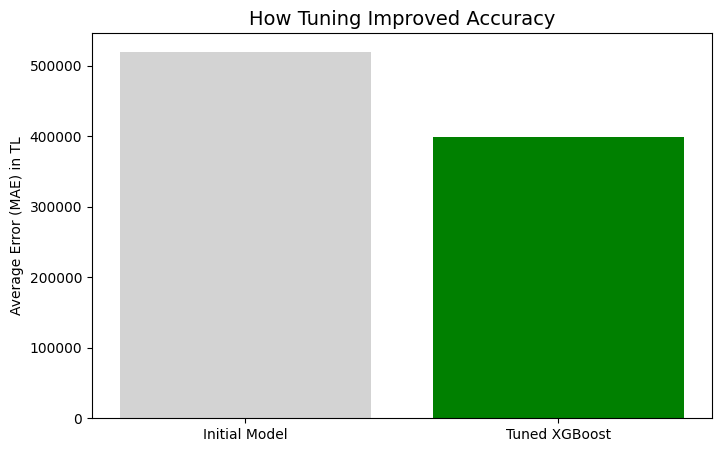

In [148]:
# Comparison of your errors
labels = ['Initial Model', 'Tuned XGBoost']
errors = [520000, 398196] # 520k is our estimate of the first model

plt.figure(figsize=(8, 5))
plt.bar(labels, errors, color=['lightgrey', 'green'])
plt.ylabel('Average Error (MAE) in TL')
plt.title('How Tuning Improved Accuracy', fontsize=14)
plt.show()